# Exercises XP: Deep Dive into LLM Concepts

Week 12, Day 4

## What You'll Learn
- Deepen your understanding of core LLM concepts.
- Apply theory to practical scenarios.
- Develop critical thinking on LLM applications and ethics.
- Compare/contrast transformer architectures and techniques.

## What You Will Create
- Comparative tables (NLP paradigms and BERT variants)
- Architecture/application write-ups
- Pretraining benefits and ethical considerations
- Analyses on attention and positional encoding
- Model selection justifications across tasks
- Notes on softmax temperature and its effects
- Scenario-based answers applying learned concepts

## 🌟 Exercise 1: Traditional vs. Modern NLP: Comparative Analysis

### 1) Comparison table

| Aspect | Traditional NLP | Modern NLP |
|---|---|---|
| **Feature Engineering** | **Manual**: experts design the features (bag-of-words, TF-IDF, n-grams, part-of-speech tags, lexicons, handcrafted rules, regular expressions). | **Automatic**: the network learns its own features directly from raw text (subword tokens) through its layers (representation learning). |
| **Word Representations** | **Sparse or static**: one-hot / TF-IDF vectors, then static embeddings (Word2Vec, GloVe) where a word has **one vector whatever the context** ("bank" is the same in "river bank" and "bank account"). | **Contextual**: each token gets a vector that depends on the whole sentence (ELMo, BERT, GPT), so "bank" gets different representations in different contexts. |
| **Model Architectures** | **Shallow**: Naïve Bayes, logistic regression, SVM, HMM, CRF, decision trees; at most a few layers (early RNNs). | **Deep**: Transformers with tens of layers, self-attention and hundreds of millions to hundreds of billions of parameters. |
| **Training Methodology** | **Task-specific**: one model trained from scratch for each task on a labelled dataset. | **Pre-training + fine-tuning**: a general model is pre-trained once on massive unlabelled text (self-supervised), then fine-tuned (or prompted) for many tasks. |
| **Key Examples of Models** | Naïve Bayes spam filters, TF-IDF + SVM text classifiers, HMM part-of-speech taggers, CRF named-entity recognisers, n-gram language models, Word2Vec / GloVe. | BERT, RoBERTa, GPT-2/3/4, T5, BART, LLaMA, Claude, Gemini. |
| **Advantages** | Fast and cheap to train, runs on a CPU, needs little data for simple tasks, **interpretable** (we know which words drive a decision), predictable behaviour. | State-of-the-art accuracy, understands context, ambiguity and long-range dependencies, one model reused for many tasks and languages, little labelled data needed thanks to transfer learning, can generate fluent text. |
| **Disadvantages** | Requires a lot of expert work for features, poor handling of context, word order, synonyms and ambiguity, does not transfer between tasks, quickly reaches a performance ceiling. | Very expensive to pre-train (GPUs, energy, data), large models are slow and heavy to deploy, "black box" with limited interpretability, can hallucinate and reproduce biases from their training data. |

### 2) Impact on scalability and efficiency

The move to modern NLP replaced manual feature engineering with **representation learning**: instead of experts writing new features for every task and language, the model learns useful representations automatically from raw text, so adding a new task or language mostly means adding data, not engineering. The Transformer architecture, unlike RNNs, processes all tokens of a sequence **in parallel**, which fully exploits **GPUs and TPUs** and made it possible to train on billions of words; performance then keeps improving as we scale data, model size and compute (scaling laws). **Transfer learning** changed the economics: the very expensive pre-training is done once, and the same model is fine-tuned in minutes or hours on a few thousand examples, or even used directly with prompts (zero/few-shot), so a single model serves hundreds of applications. On the other hand, *inference* efficiency became a new challenge: large models are costly to run, which drove the development of distillation (DistilBERT), quantisation, pruning and efficient architectures. Overall, NLP became much more scalable in terms of development effort and quality, but more demanding in terms of computing resources.

## 🌟 Exercise 2: LLM Architecture and Application Scenarios

### BERT (Bidirectional Encoder Representations from Transformers)
- **Architecture:** **encoder-only** Transformer, **bidirectional**: every token attends to all the tokens on its left *and* right. Pre-trained with **Masked Language Modeling** (predict ~15% of the tokens that were masked) and, historically, **Next Sentence Prediction**. It produces contextual embeddings for each token (and a `[CLS]` summary vector), but it is not designed to generate text.
- **Application:** **extractive question answering and search**, e.g. a customer-support system that finds the exact answer span to "What is the refund deadline?" in a company's policy documents (as in SQuAD), or Google Search understanding queries. Also: sentiment classification, named-entity recognition, spam detection.
- **Why it fits:** these tasks require **understanding** a full text, not producing new text. Seeing the whole context in both directions helps interpret every word (e.g. "not" before "refundable", or a date mentioned after the question word), and the token-level embeddings are perfect to classify a sentence or to point at the start and end of the answer span.

### GPT (Generative Pre-trained Transformer)
- **Architecture:** **decoder-only** Transformer, **unidirectional** (left to right): a **causal mask** prevents each token from seeing the future. Pre-trained with **Causal Language Modeling**: predict the next token given all the previous ones. It generates text **autoregressively**, one token at a time.
- **Application:** **conversational assistants and content generation**, e.g. a chatbot that drafts emails, answers open questions or writes code (ChatGPT, GitHub Copilot).
- **Why it fits:** generation is exactly the task GPT was trained on: continuing a text token by token. The causal setup matches the way text is produced, it scales very well, and with instruction tuning a single decoder handles any task expressed as a prompt ("Summarise…", "Write a Python function that…").

### T5 (Text-to-Text Transfer Transformer)
- **Architecture:** **encoder-decoder** Transformer: a bidirectional encoder reads the whole input, and an autoregressive decoder generates the output while attending to the encoder through **cross-attention**. Every task is framed as **text-to-text** ("translate English to German: …", "summarize: …"), and it is pre-trained with **span corruption** (masked spans of text are replaced by sentinel tokens that the decoder must regenerate).
- **Application:** **abstractive summarisation** of long documents (e.g. summarising news articles or meeting transcripts) and **machine translation**.
- **Why it fits:** these tasks transform an input text into a *different* output text. The encoder fully understands the source (in both directions), and the decoder generates a new, fluent sequence of a different length, constantly looking back at the relevant parts of the source through cross-attention. The unified text-to-text format also makes it easy to fine-tune one model on several such tasks.

## 🌟 Exercise 3: Benefits and Ethics of Pre-training

### Benefits (in my own words)
1. **Improved generalization:** during pre-training the model sees an enormous variety of texts (topics, styles, domains), so it learns general knowledge of the language rather than the quirks of one small dataset; after fine-tuning it therefore performs better on new examples it has never seen.
2. **Less labeled data:** the model already "knows" grammar, vocabulary and many facts, so it only needs a few hundred or thousand labelled examples to learn a new task, instead of the hundreds of thousands a model trained from scratch would require; labelling is expensive, so this is a huge practical gain.
3. **Faster fine-tuning:** the weights start from a very good point, so adapting them to a task takes a few epochs (minutes or hours on one GPU) instead of weeks of training from random weights.
4. **Transfer learning:** knowledge learned on one task or domain is reused for another: the same pre-trained model can be fine-tuned for sentiment analysis, translation or question answering, and even transfer to low-resource languages or specialised domains (medical, legal).
5. **Robustness:** having seen noisy, diverse text, pre-trained models cope better with typos, slang, unusual phrasings and inputs slightly different from the fine-tuning data (distribution shift) than task-specific models.

### Ethical concerns
- **Bias and discrimination:** web-scale data contains stereotypes (gender, ethnicity, religion, age); the model learns and can amplify them, e.g. associating "nurse" with women and "engineer" with men, or producing unfair outputs in hiring or credit tools.
- **Misinformation and hallucinations:** the training data contains false information, and the model can generate fluent, convincing but wrong statements; it can also be used to produce fake news or propaganda at scale.
- **Misuse:** phishing emails, spam, impersonation, academic cheating, generation of malicious code or harmful instructions.
- **Privacy:** personal data present in the scraped data (names, emails, addresses, medical information) can be memorised and regurgitated by the model.
- **Copyright and consent:** texts and code used without the authors' consent; **environmental cost** of training (energy, carbon footprint); concentration of power in a few large companies.

### Mitigations
- **Data curation:** filter toxic, hateful and low-quality content, deduplicate, balance the representation of groups and languages, remove personal data (PII scrubbing), document the datasets (datasheets).
- **Privacy techniques:** differential privacy during training, removal of memorised sensitive content, opt-out mechanisms for content owners.
- **Alignment and safety:** fine-tuning on human-written demonstrations, **RLHF** (reinforcement learning from human feedback) or constitutional methods to make the model helpful and harmless, refusals for dangerous requests, safety classifiers and content filters on inputs and outputs.
- **Evaluation and audits:** bias benchmarks, red-teaming, external audits, model cards describing limits and intended uses.
- **Grounding and transparency:** retrieval-augmented generation with sources to reduce hallucinations, watermarking / labelling AI-generated content, usage policies and monitoring of abuse, keeping a human in the loop for high-stakes decisions.

## 🌟 Exercise 4: Transformer Architecture Deep Dive

### Self-Attention & Multi-Head Attention

**How self-attention works.** Each token of the input starts as an embedding (plus a positional encoding). For every token, the layer computes three vectors with learned matrices: a **query** Q = xW_Q ("what am I looking for?"), a **key** K = xW_K ("what do I contain / how can I be found?") and a **value** V = xW_V ("what information do I pass on?"). The relevance of token *j* for token *i* is the dot product of query *i* with key *j*, divided by √d_k to keep the values in a reasonable range. A **softmax** over all positions turns these scores into **attention weights** that sum to 1. The new representation of token *i* is the **weighted sum of all the values**: tokens with a high weight contribute most. In matrix form: Attention(Q, K, V) = softmax(QKᵀ / √d_k) V. Every token is thus re-written as a mixture of the information of the tokens that matter for it, all positions being computed in parallel. In a decoder, a causal mask sets the scores of future tokens to −∞ so that a token only sees the past.

**Why multi-head attention.** A single attention head computes one set of weights, i.e. one way of relating the words; it has to average very different kinds of relations (syntax, meaning, coreference) into one distribution. **Multi-head attention** runs *h* heads in parallel (e.g. 12 in BERT-base), each with its own W_Q, W_K, W_V projecting the embeddings into a smaller **subspace** (e.g. 768 / 12 = 64 dimensions). Each head can specialise in a different type of relation; their outputs are concatenated and mixed by an output matrix W_O. The cost is similar to one big head, but the model captures several relations at the same time, which makes the representations richer and the training more stable.

**Example sentence:** *"The chef who trained in Lyon burned the sauce because she was distracted by the phone."*
- **Head A - coreference:** for the token "she", the strongest weight goes to "chef" (not "sauce" or "Lyon"), linking the pronoun to the person it refers to.
- **Head B - subject–verb / syntax:** "burned" attends to its subject "chef" (skipping the relative clause "who trained in Lyon") and to its object "sauce".
- **Head C - causal / discourse relation:** "because" attends to "burned" and "distracted", linking the effect and its cause.
- **Head D - local / modifier relations:** "trained" attends to "in Lyon", and "distracted" attends to "by the phone".
A single head would have to blend all of these into one weight distribution; multiple heads keep them separate and combine them afterwards.

### Pre-training Objectives

**MLM vs CLM.**

| | Masked Language Modeling (MLM) | Causal Language Modeling (CLM) |
|---|---|---|
| Task | Hide ~15% of the tokens and predict them from the **whole** sentence | Predict the **next** token from the previous ones only |
| Context | Bidirectional (left and right) | Unidirectional (left to right, causal mask) |
| Typical models | BERT, RoBERTa, ALBERT, XLM-R (encoders) | GPT family, LLaMA, Claude (decoders) |
| Strength | Deep understanding of each token in context → great for classification, NER, extractive QA, embeddings | Natural text generation, prompting, few-shot learning |
| Weakness | Cannot generate text naturally; learns only from the 15% masked tokens per sentence; `[MASK]` never appears at inference | Each token only sees the past, so representations are less suited for some understanding tasks (though very large models compensate) |

**When to prefer each.** **MLM** is better for a **legal-clause classifier** or a **named-entity recogniser** in medical reports: deciding whether "discharge" means a hospital discharge or a fluid depends on words both before and after it, and nothing has to be generated. **CLM** is better for an **email-reply assistant** or a **story generator**: the model must write new text word by word, exactly what next-token prediction trains it to do.

**Next Sentence Prediction (NSP).** The original BERT added NSP: given two segments A and B, predict whether B really follows A in the corpus (50%) or is a random sentence (50%). The goal was to teach the model **relations between sentences**, useful for tasks with sentence pairs like question answering and natural language inference. Later work (notably **RoBERTa**) showed that NSP brings little or no benefit and can even hurt: the task is too easy (random sentences are usually about a different topic, so the model just detects topic changes) and it forces training on shorter segments. Removing NSP and training on long, contiguous texts with more data gave better results, so modern models drop it or replace it with harder objectives such as **Sentence Order Prediction** (ALBERT: are two consecutive segments in the right order?).

### Transformer Model Selection

- **Customer reviews → positive / negative / neutral: Encoder-only (e.g. BERT, RoBERTa, DistilBERT).** This is a **classification** task: we need to understand the whole review, not generate text. A bidirectional encoder reads every word with its full context (it correctly interprets "not bad at all" or "I expected better") and a small classification head on the `[CLS]` representation gives the three classes. Encoders are smaller and faster than generative models for the same accuracy, cheap to fine-tune, and easy to scale to millions of reviews.
- **Creative, engaging chatbot: Decoder-only (e.g. GPT, LLaMA).** The system must **generate** open-ended, fluent and varied answers token by token, conditioned on the conversation history — exactly what causal language modeling does. Decoder-only models are the best at free generation, can be instruction-tuned / RLHF-tuned for dialogue, and their creativity can be tuned with sampling parameters (temperature, top-p).
- **Translating technical documents EN → ES: Encoder-Decoder (e.g. T5, mBART, MarianMT).** Translation maps an input sequence to an output sequence of a different length. The **encoder** builds a full bidirectional understanding of the English sentence (important for technical terms whose meaning depends on the whole sentence), and the **decoder** generates the Spanish text while attending to the relevant source words through **cross-attention**, which helps keep the translation faithful and complete (no omitted or invented content) — essential for technical documents.

### Positional Encoding

**Purpose.** Self-attention treats its input as a **set**: the attention weights depend only on the content of the tokens, so if we shuffled the words, every token would get exactly the same output (the operation is permutation-invariant). Unlike RNNs, a Transformer has no built-in notion of order. **Positional encodings** add information about each token's position to its embedding, either with fixed sinusoidal functions of different frequencies (original Transformer), learned position embeddings (BERT, GPT-2), or relative/rotary encodings (T5, RoPE in LLaMA) that encode the *distance* between tokens. This lets the model use word order, which carries a lot of meaning (syntax, who does what to whom, negation scope).

**Example of failure without it.** *"The dog bit the man"* and *"The man bit the dog"* contain exactly the same tokens; without positional encoding the model would produce the same representations for both and could not tell who bit whom. Likewise, a sentiment model could not distinguish *"not good, just bad"* from *"not bad, just good"*, and a translation system could produce the right words in a random order.

## 🌟 Exercise 5: BERT Variations: Choose Your Detective

### Best fit per scenario
- **Scenario 1 - real-time sentiment analysis on a mobile app with limited resources: DistilBERT.** Obtained by knowledge distillation from BERT, it is about **40% smaller and 60% faster** while keeping about 97% of BERT's performance on language understanding, which is ideal for low latency on a phone (and it can be further quantised).
- **Scenario 2 - research on legal documents requiring high accuracy: RoBERTa.** It is BERT trained "better": 10× more data, longer training, larger batches, dynamic masking and no NSP, which gives higher accuracy on understanding benchmarks. When accuracy matters more than cost, a large RoBERTa (ideally further pre-trained on legal text) is the best choice.
- **Scenario 3 - global customer support in multiple languages: XLM-RoBERTa.** Pre-trained with MLM on 2.5 TB of CommonCrawl text in **100 languages**, it handles all of them with one model and allows cross-lingual transfer: fine-tune on English support tickets and it works reasonably well on Spanish, Arabic or Hindi tickets.
- **Scenario 4 - efficient pre-training with token replacement detection: ELECTRA.** Instead of predicting masked tokens, a small generator replaces some tokens with plausible alternatives and the main model (discriminator) learns to detect **which tokens were replaced** (replaced token detection). It learns from *every* token instead of only 15%, so it reaches BERT-level accuracy with a fraction of the pre-training compute.
- **Scenario 5 - efficient NLP in resource-constrained environments: ALBERT.** It shares the parameters across all its layers and factorises the embedding matrix, so it has **far fewer parameters** (ALBERT-base: 12M vs 110M for BERT-base) and a much smaller memory footprint, which is ideal when storage/memory is the constraint. (If inference *speed* is the main constraint, DistilBERT is also a good option, since ALBERT still runs all its layers.)

### Comparison table

| Model | Training differences | Size / Efficiency | Innovations | Ideal use cases |
|---|---|---|---|---|
| **RoBERTa** | Same architecture as BERT, trained longer on ~160 GB of text (10× BERT), bigger batches, more steps; MLM only (no NSP) | Same size as BERT (125M base / 355M large), same inference cost; expensive pre-training | Dynamic masking (new mask pattern at each epoch), removal of NSP, byte-level BPE vocabulary, tuned hyperparameters | High-accuracy understanding tasks: classification, QA, NLI, domain research (legal, scientific) |
| **ALBERT** | MLM + Sentence Order Prediction (SOP) instead of NSP | Very few parameters (12M base, 18M large) thanks to sharing; small memory, but compute per layer similar to BERT | Cross-layer parameter sharing, factorised embedding parameterisation, SOP objective | Memory-constrained deployments, large models with a small footprint, sentence-coherence tasks |
| **DistilBERT** | Knowledge distillation from BERT-base during pre-training (student mimics the teacher's outputs + MLM + cosine embedding loss) | 66M parameters, 6 layers: ~40% smaller, ~60% faster, keeps ~97% of BERT's performance | Distillation (triple loss), removal of token-type embeddings and pooler | Real-time and mobile/edge applications, high-volume inference with low cost |
| **ELECTRA** | Generator–discriminator pre-training: replaced token detection on all tokens | Base ~110M; matches or beats BERT/RoBERTa with much less pre-training compute; small versions are very efficient | Replaced Token Detection, learning signal from 100% of tokens, small generator trained jointly | Efficient pre-training on limited compute, strong classifiers/understanding models with small budgets |
| **XLM-RoBERTa (XLM-R)** | RoBERTa-style MLM on 2.5 TB of filtered CommonCrawl in 100 languages | Large (270M base, 550M large) because of its 250k-token multilingual vocabulary | Massively multilingual training, shared SentencePiece vocabulary, strong cross-lingual transfer | Multilingual classification, NER and QA, cross-lingual transfer to low-resource languages, global customer support |

## 🌟 Exercise 6: Softmax Temperature: The Randomness Regulator

The model outputs a score (logit) z_i for every token of the vocabulary; the probabilities are p_i = exp(z_i / T) / Σ_j exp(z_j / T). Dividing by **T < 1** increases the gaps between the scores (sharper distribution), **T > 1** reduces them (flatter distribution). The cells below show this numerically and on real GPT-2 generations.

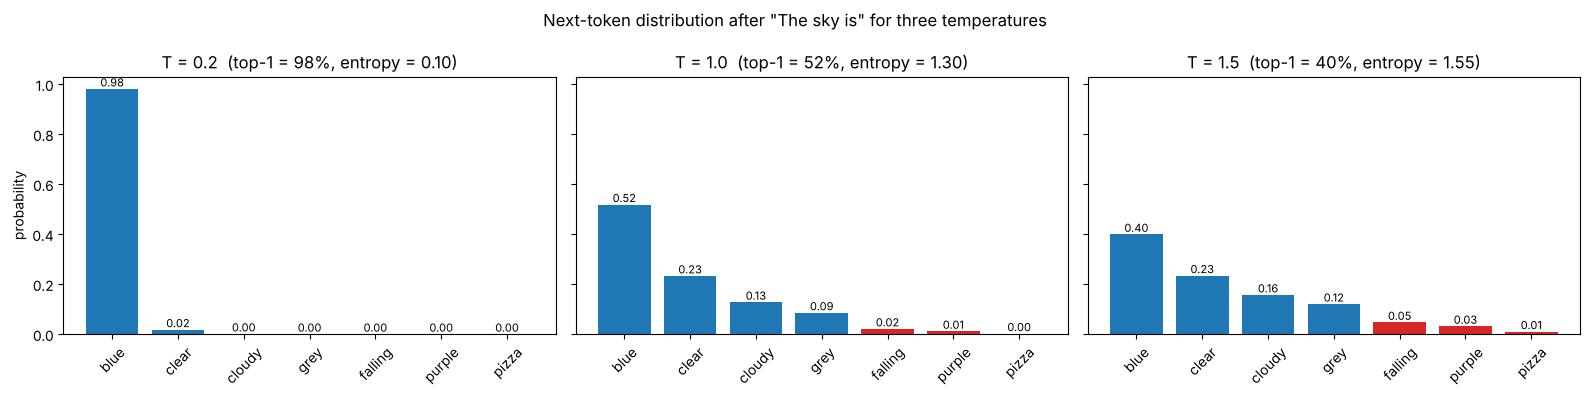

T=0.2: P(blue)=0.981 | P(unlikely words: falling/purple/pizza)=0.000
T=1.0: P(blue)=0.519 | P(unlikely words: falling/purple/pizza)=0.035
T=1.5: P(blue)=0.399 | P(unlikely words: falling/purple/pizza)=0.089


In [1]:
import numpy as np
import matplotlib.pyplot as plt

tokens = ["blue", "clear", "cloudy", "grey", "falling", "purple", "pizza"]
logits = np.array([4.0, 3.2, 2.6, 2.2, 0.8, 0.2, -1.5])   # scores for the next word after "The sky is"

def softmax_with_temperature(z, T):
    e = np.exp((z - z.max()) / T)
    return e / e.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, T in zip(axes, [0.2, 1.0, 1.5]):
    p = softmax_with_temperature(logits, T)
    entropy = -(p * np.log(p)).sum()
    ax.bar(tokens, p, color=['tab:blue'] * 4 + ['tab:red'] * 3)
    ax.set_title(f"T = {T}  (top-1 = {p.max():.0%}, entropy = {entropy:.2f})")
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(p):
        ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=8)
axes[0].set_ylabel("probability")
fig.suptitle('Next-token distribution after "The sky is" for three temperatures')
plt.tight_layout(); plt.show()

for T in [0.2, 1.0, 1.5]:
    p = softmax_with_temperature(logits, T)
    print(f"T={T}: P(blue)={p[0]:.3f} | P(unlikely words: falling/purple/pizza)={p[4:].sum():.3f}")

### 1) Temperature Scenarios

- **T = 0.2 (low): almost deterministic and conservative.** The distribution becomes very peaked: in the example above, "blue" gets **98%** of the probability and the unlikely words practically 0%. The model nearly always picks the most probable token, so the output is coherent, factual-sounding and predictable, but repetitive and generic; two runs give almost the same text, and in long generations it tends to loop (see the GPT-2 demo below, where T = 0.2 repeats "I opened the box and found a small box…"). Good for factual answers, code, extraction, summaries.
- **T = 1.0 (neutral): the model's original distribution.** Probabilities are used as learned ("blue" 52%, "clear", "cloudy" and "grey" share most of the rest, unlikely words 3.5%). The output is natural and varied while staying mostly coherent; this is the reference behaviour, a balance between diversity and quality.
- **T = 1.5 (high): more random and creative, less reliable.** The distribution is flattened: "blue" drops to 40% and the unlikely words ("falling", "purple", "pizza") rise to **9%**. The text becomes more surprising and original, but also more likely to drift off-topic, contain errors, strange word choices or incoherent sentences. Useful for brainstorming or poetry, risky for anything that must be correct.

### 2) Application Design

**Bedtime stories for children (creativity vs coherence).** I would use a **moderate temperature of about 0.7–0.9** combined with **top-p ≈ 0.9** (nucleus sampling). This gives enough randomness for varied, imaginative stories (different names, places, plot twists every night) while cutting off the long tail of very improbable tokens that would produce nonsense. The creativity can be split by stage: a slightly higher temperature (≈ 1.0) to brainstorm the story idea and characters, then ≈ 0.7 to write the actual text so that sentences stay simple, grammatical and consistent with the child's name and preferences. I would also add a repetition penalty, a length limit and a safety filter so that the content stays age-appropriate. Temperatures above ~1.2 would be avoided: stories would become incoherent or drift into unsuitable content.

**Financial report summaries (accuracy and reliability).** I would use a **very low temperature (0–0.2), ideally greedy decoding or beam search** (deterministic), so that the model always picks the most likely tokens and produces the same summary for the same report. The goal is faithfulness, not creativity: numbers, company names, dates and trends must be copied exactly from the source. Sampling at a high temperature could replace "€2.3 million" by "€3.2 million" or invent a trend. I would also ground the model on the report (retrieval / extractive constraints), check numbers automatically against the source, and keep a human review for publication.

### 3) Temperature & Bias

Temperature does not create or remove the biases learned by the model, but it changes **how they show up in the outputs**:
- **Low temperature** always picks the most probable continuation, so the output reflects the **dominant pattern of the training data**. If that pattern is a stereotype, it appears *systematically* and is amplified: every generated story about "a nurse" uses "she", every "CEO" is a man. The bias is concentrated into a single, repeated answer.
- **High temperature** flattens the distribution: less frequent continuations (including more diverse, counter-stereotypical ones) appear more often, which can **dampen** the systematic bias, but it also gives more probability to rare **toxic or offensive** completions that the model had learned but ranked low, and to factual errors. So a high temperature makes outputs less predictable and harder to control.

**Practical example:** a recruitment tool generates candidate descriptions with the prompt "The engineer walked in and". At T = 0.2, almost 100% of the generations continue with "he", reinforcing the stereotype in every document. At T = 1.5, "she" or "they" appear more often, but occasionally the model also produces an inappropriate comment about the person's appearance. Neither setting fixes the problem: temperature is only a sampling knob, and bias must be addressed at the data and training level (balanced data, debiasing, RLHF) and checked with bias evaluations on the outputs.

### (Optional) Quick Generation Demo Across Temperatures
Requires `transformers` and a model download.

In [2]:
import os, warnings
warnings.filterwarnings("ignore")
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, set_seed
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
import torch

model_name = "gpt2"  # a small causal LM
prompt = "When I opened the old wooden box, I found"

pipe = pipeline(
    "text-generation",
    model=AutoModelForCausalLM.from_pretrained(model_name),
    tokenizer=AutoTokenizer.from_pretrained(model_name),
    device=0 if torch.cuda.is_available() else -1,
)

for T in [0.2, 1.0, 1.5]:
    print("--- Temperature:", T)
    for run in range(2):
        set_seed(run)
        out = pipe(prompt, max_new_tokens=40, temperature=T, do_sample=True, pad_token_id=pipe.tokenizer.eos_token_id)
        print(f"[sample {run + 1}]", out[0]["generated_text"].replace("\n", " "))  # Inspect how style changes with T
    print()

--- Temperature: 0.2


[sample 1] When I opened the old wooden box, I found a small box with a few pieces of paper. I opened the box and found a small box with a few pieces of paper. I opened the box and found a small box with a few pieces of


[sample 2] When I opened the old wooden box, I found a small box with a small piece of paper on it. I opened it and found a small piece of paper. I opened it and found a small piece of paper. I opened it and found a

--- Temperature: 1.0


[sample 1] When I opened the old wooden box, I found a letter from the first officer of the "A" Brigade, who was quite eager and impressed with the contents of the box. He asked me to make a small film on the case. I did


[sample 2] When I opened the old wooden box, I found a book. It was in the corner. I told myself, I should never have to close it again so the old wooden box was easy to access. I said, wait and my books were in

--- Temperature: 1.5


[sample 1] When I opened the old wooden box, I found a letter: "We've taken my business back to Texas." I said "I thought you did?" They looked over my arm and I wrote "you know it's a big job when you buy


[sample 2] When I opened the old wooden box, I found an old magazine lying there in the corner. After reading it, I looked around, unsure of what else contained the old magazine I was holding. There were five bullet proofs in it; each for $



**Observations on the GPT-2 demo** (two samples per temperature, same prompt):
- **T = 0.2:** both samples are almost identical and immediately fall into a **repetition loop** ("I opened the box and found a small box with a few pieces of paper…" repeated). Very coherent locally, but boring and degenerate over a longer text.
- **T = 1.0:** each sample tells a different story (a letter from an officer, a book in the corner); the text is varied and mostly grammatical, with a few odd sentences, as expected from a small model like GPT-2.
- **T = 1.5:** the samples are more surprising (a letter about a business moving to Texas, "bullet proofs" in a magazine), with more unusual words and less logical continuity: creativity increases but coherence decreases.

This confirms the theory: the temperature is the main knob between **reliability/coherence** (low T) and **diversity/creativity** (high T).